In [44]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error




In [45]:

PV_CSV_PATH = "pv_data.csv"
WEATHER_CSV_PATH = "weather_data.csv"

TARGET_COL = "pv"

ALL_FEATURES = [
    "soc","load","pv","sun_hours","temperature","glob_radiation_wm2",
    "hour_sin","hour_cos","dow_sin","dow_cos","woy_sin","woy_cos"
]

PAST_FEATURES = ALL_FEATURES.copy()

EXOG_FEATURES = [
    "temperature","sun_hours","glob_radiation_wm2",
    "hour_sin","hour_cos","dow_sin","dow_cos","woy_sin","woy_cos"
]

# Time-series lags (hours)
LAGS = [1, 2, 3, 4, 5, 6, 12]

In [ ]:
#  PREPROCESSING PIPELINE


def load_and_merge():
    # --- Load PV data (5-min → hourly) ---
    pv_df = pd.read_csv(
        PV_CSV_PATH, sep=",",
        parse_dates=["timestamp"],
        index_col="timestamp"
    )
    pv_df = pv_df.apply(pd.to_numeric, errors="coerce")
    pv_hourly = pv_df.resample("1h").mean()

    # --- Load weather data ---
    weather_df = pd.read_csv(
        WEATHER_CSV_PATH,
        sep=",",
        parse_dates=["time"],
        index_col="time"
    )
    if weather_df.index.tz is not None:
        weather_df.index = weather_df.index.tz_convert(None)
    weather_df = weather_df.apply(pd.to_numeric, errors="coerce")

    # date range fix
    weather_df = weather_df.loc["2024-07-01":"2025-10-20"]

    # --- Merge PV + weather ---
    df = pv_hourly.join(weather_df, how="inner")

    df = df.iloc[3500:] # to get rid of earlier dates which have almost no pv output, since it makes harder to predict summer months

    # --- Time features ---
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["weekofyear"] = df.index.isocalendar().week

    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    df["dow_sin"]  = np.sin(2*np.pi*df["dayofweek"]/7)
    df["dow_cos"]  = np.cos(2*np.pi*df["dayofweek"]/7)
    df["woy_sin"]  = np.sin(2*np.pi*df["weekofyear"]/52)
    df["woy_cos"]  = np.cos(2*np.pi*df["weekofyear"]/52)

    df = df[ALL_FEATURES]
    df = df.replace(["None","nan","NaN",""], pd.NA).ffill().bfill()

    return df


def scale_and_split(df):
    split_train = int(len(df) * 0.7)
    split_val   = int(len(df) * 0.85)

    df_train = df.iloc[:split_train]
    df_val   = df.iloc[split_train:split_val]
    df_test  = df.iloc[split_val:]

    scaler_y = StandardScaler()
    scaler_X = StandardScaler()

    scaler_y.fit(df_train[[TARGET_COL]])
    scaler_X.fit(df_train[PAST_FEATURES])

    df_scaled = df.copy()
    df_scaled[PAST_FEATURES] = scaler_X.transform(df[PAST_FEATURES])
    df_scaled[TARGET_COL] = scaler_y.transform(df[[TARGET_COL]])

    return df_scaled, scaler_y, scaler_X, split_train, split_val


def create_lag_features(df_scaled, split_train, split_val):

    df_ml = df_scaled.copy()

    # --- build lags ---
    for lag in LAGS:
        for col in PAST_FEATURES:
            df_ml[f"{col}_lag{lag}"] = df_ml[col].shift(lag)

    df_ml = df_ml.dropna()

    # --- ML split ---
    df_train_ml = df_ml.iloc[:split_train]
    df_val_ml   = df_ml.iloc[split_train:split_val]
    df_test_ml  = df_ml.iloc[split_val:]

    FEATURE_COLS = [c for c in df_ml.columns if "lag" in c]

    X_train = df_train_ml[FEATURE_COLS]
    y_train = df_train_ml[TARGET_COL]
    X_val   = df_val_ml[FEATURE_COLS]
    y_val   = df_val_ml[TARGET_COL]
    X_test  = df_test_ml[FEATURE_COLS]
    y_test  = df_test_ml[TARGET_COL]

    return X_train, y_train, X_val, y_val, X_test, y_test, FEATURE_COLS



# MAIN PREPROCESS FUNCTION

def preprocess_all():
    df = load_and_merge()
    df_scaled, scaler_y, scaler_X, split_train, split_val = scale_and_split(df)
    X_train, y_train, X_val, y_val, X_test, y_test, FEATURES = create_lag_features(
        df_scaled, split_train, split_val
    )

    return (
        df, df_scaled,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        scaler_y, FEATURES
    )


# Run preprocessing
(
    df, df_scaled,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    scaler_y, FEATURES
) = preprocess_all()

print("Shapes:")
print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)


Shapes:
Train: (5563, 84)
Val:   (1192, 84)
Test:  (1181, 84)


In [47]:
import optuna
from sklearn.metrics import mean_squared_error

# testing different hyperparams

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "objective": "reg:squarederror",
        "random_state": 42,
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    pred_val = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, pred_val))
    return rmse
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler = sampler)
study.optimize(objective, n_trials=200)

print("Best parameters:", study.best_params)
print("Best RMSE:", study.best_value)


[I 2025-11-16 21:36:23,708] A new study created in memory with name: no-name-b71c774f-d0bf-4692-b454-e218f14c14d5
[I 2025-11-16 21:36:24,883] Trial 0 finished with value: 0.4438708292115924 and parameters: {'n_estimators': 500, 'learning_rate': 0.19063571821788408, 'max_depth': 8, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 1.2022300234864176}. Best is trial 0 with value: 0.4438708292115924.
[I 2025-11-16 21:36:27,123] Trial 1 finished with value: 0.2875976229215582 and parameters: {'n_estimators': 767, 'learning_rate': 0.013911053916202464, 'max_depth': 10, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 1.0495128632644757}. Best is trial 1 with value: 0.2875976229215582.
[I 2025-11-16 21:36:28,376] Trial 2 finished with value: 0.2966580

Best parameters: {'n_estimators': 382, 'learning_rate': 0.07307129633310191, 'max_depth': 6, 'subsample': 0.9384680265007592, 'colsample_bytree': 0.9539000821205074, 'min_child_weight': 9, 'gamma': 0.16537789281252951, 'reg_alpha': 0.1373353181000095, 'reg_lambda': 0.7093314555029226}
Best RMSE: 0.1927780365318246



Final Model RMSEs (Using Tuned Parameters):
Val RMSE: 0.1927780365318246
Test RMSE: 0.26333121574217666


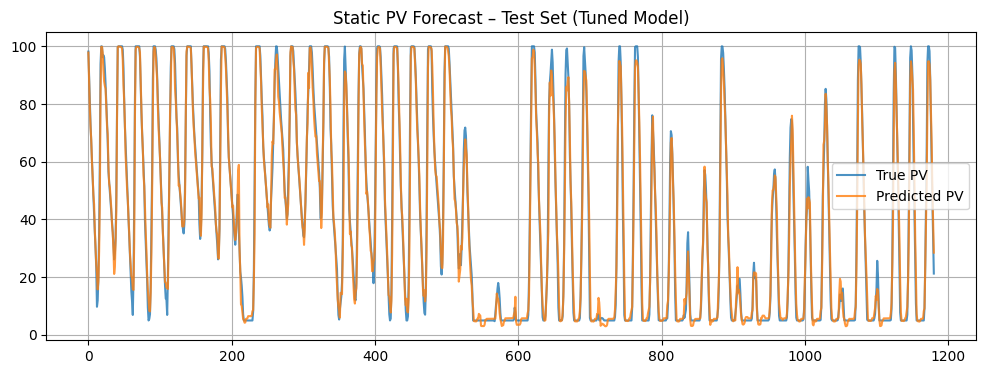

Next-step PV prediction: 28.505897288507494


In [48]:
best_params = study.best_params
best_params["objective"] = "reg:squarederror"
best_params["random_state"] = 42

model = xgb.XGBRegressor(**best_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# --- Predictions ---
pred_val = model.predict(X_val)
pred_test = model.predict(X_test)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("\nFinal Model RMSEs (Using Tuned Parameters):")
print("Val RMSE:", rmse(y_val, pred_val))
print("Test RMSE:", rmse(y_test, pred_test))


# INVERSE SCALE & PLOT

pred_test_inv = scaler_y.inverse_transform(pred_test.reshape(-1,1)).flatten()
y_test_inv    = scaler_y.inverse_transform(y_test.values.reshape(-1,1)).flatten()

plt.figure(figsize=(12,4))
plt.plot(y_test_inv, label="True PV", alpha=0.8)
plt.plot(pred_test_inv, label="Predicted PV", alpha=0.8)
plt.legend()
plt.grid(True)
plt.title("Static PV Forecast – Test Set (Tuned Model)")
plt.show()

# Next-step prediction
next_pred_scaled = model.predict(X_test.iloc[-1:])[0]
next_pred = scaler_y.inverse_transform([[next_pred_scaled]])[0][0]
print("Next-step PV prediction:", next_pred)